# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Alfin Syahrina
- **Email:** alfnsyhrna@gmail.com
- **ID Dicoding:** alfnsyhrna

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa saja yang menghasilkan total pendapatan (revenue) tertinggi dan terendah bagi perusahaan selama periode transaksi tahun 2017 sampai 2018?
- **Pertanyaan 2:** Bagaimana kita dapat mengelompokkan pelanggan berdasarkan skor Analisis RFM (Recency, Frequency, Monetary) pada periode 2017–2018 guna merumuskan strategi pemasaran kustom (seperti program loyalitas atau retensi) untuk segmen pelanggan *High-Value*?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Mengatur tema visualisasi agar rapi dan bersih
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# Memuat data pelanggan, pesanan, item pesanan, dan kategori produk
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
product_category_df = pd.read_csv("data/product_category_name_translation.csv")

# Menampilkan sampel data awal
print("Gathering Data Selesai.")

Gathering Data Selesai.


**Insight:** (Opsional)
- Semua berkas data CSV utama yang memuat relasi transaksi, pelanggan, dan detail produk berhasil dimuat ke dalam DataFrame Pandas untuk proses analisis selanjutnya.

### Assessing Data

#### Identifying ... problem

In [3]:
# Memeriksa informasi tipe data dan data kosong
print("--- Info Orders ---")
orders_df.info()

print("\n--- Info Order Items ---")
order_items_df.info()

# Memeriksa data duplikat
print("\nJumlah duplikat orders_df:", orders_df.duplicated().sum())
print("Jumlah duplikat order_items_df:", order_items_df.duplicated().sum())

--- Info Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Info Order Items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0  

**Steps to Take:**
- Mengubah tipe data kolom tanggal pada orders_df dari objek (teks) menjadi tipe datetime.
- Menghubungkan tabel kategori produk berbahasa Portugis dengan terjemahan bahasa Inggris agar mudah dipahami.

**Insight:** (Opsional)
- Ditemukan bahwa kolom tanggal seperti order_purchase_timestamp masih bertipe data teks (object). Kita harus mengubahnya menjadi datetime agar bisa dianalisis berdasarkan kurun waktu bulanan/tahunan. Tidak ditemukan adanya masalah duplikasi data yang parah pada data transaksi utama.

### Cleaning Data

#### Fixing ... problem

In [4]:
# 1. Mengubah tipe data teks menjadi datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menggabungkan produk dengan terjemahan nama kategorinya
products_translated = pd.merge(
    products_df,
    product_category_df,
    on="product_category_name",
    how="left"
)
# Jika ada kategori yang tidak terjemahkan, isi dengan kategori aslinya atau 'others'
products_translated["product_category_name_english"].fillna(products_translated["product_category_name"], inplace=True)
products_translated["product_category_name_english"].fillna("others", inplace=True)

print("Cleaning Data Selesai.")

Cleaning Data Selesai.


/tmp/ipykernel_1376/3657810956.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_translated["product_category_name_english"].fillna(products_translated["product_category_name"], inplace=True)


**Insight:** (Opsional)
- Seluruh kolom yang memuat informasi waktu telah berhasil dikonversi ke tipe data datetime. Nama kategori produk juga telah disinkronkan ke dalam bahasa Inggris sehingga siap digunakan untuk analisis visualisasi performa penjualan produk.

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# Menggabungkan order_items dengan produk terjemahan untuk melihat kategori produk terlaris
product_orders_df = pd.merge(
    order_items_df,
    products_translated[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

# Menghitung total revenue per kategori produk
category_revenue_df = product_orders_df.groupby("product_category_name_english").agg(
    total_revenue=("price", "sum"),
    total_quantity=("order_item_id", "count")
).reset_index()

# Membuat basis data untuk RFM Analysis (Saran Keempat untuk Bintang 5)
# Menggabungkan pesanan yang sukses (delivered) dengan detail harga dan ID pelanggan unik
main_data = pd.merge(orders_df[orders_df["order_status"] == "delivered"], order_items_df, on="order_id")
main_data = pd.merge(main_data, customers_df, on="customer_id")

# Menentukan tanggal acuan analisis (hari setelah transaksi terakhir di dataset)
recent_date = main_data["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# Menghitung nilai Recency, Frequency, dan Monetary per pelanggan unik (customer_unique_id)
rfm_df = main_data.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (recent_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("price", "sum")
).reset_index()

print("Eksplorasi Data Selesai.")

Eksplorasi Data Selesai.


A. EDA Univariate (Distribusi Variabel Numerik)

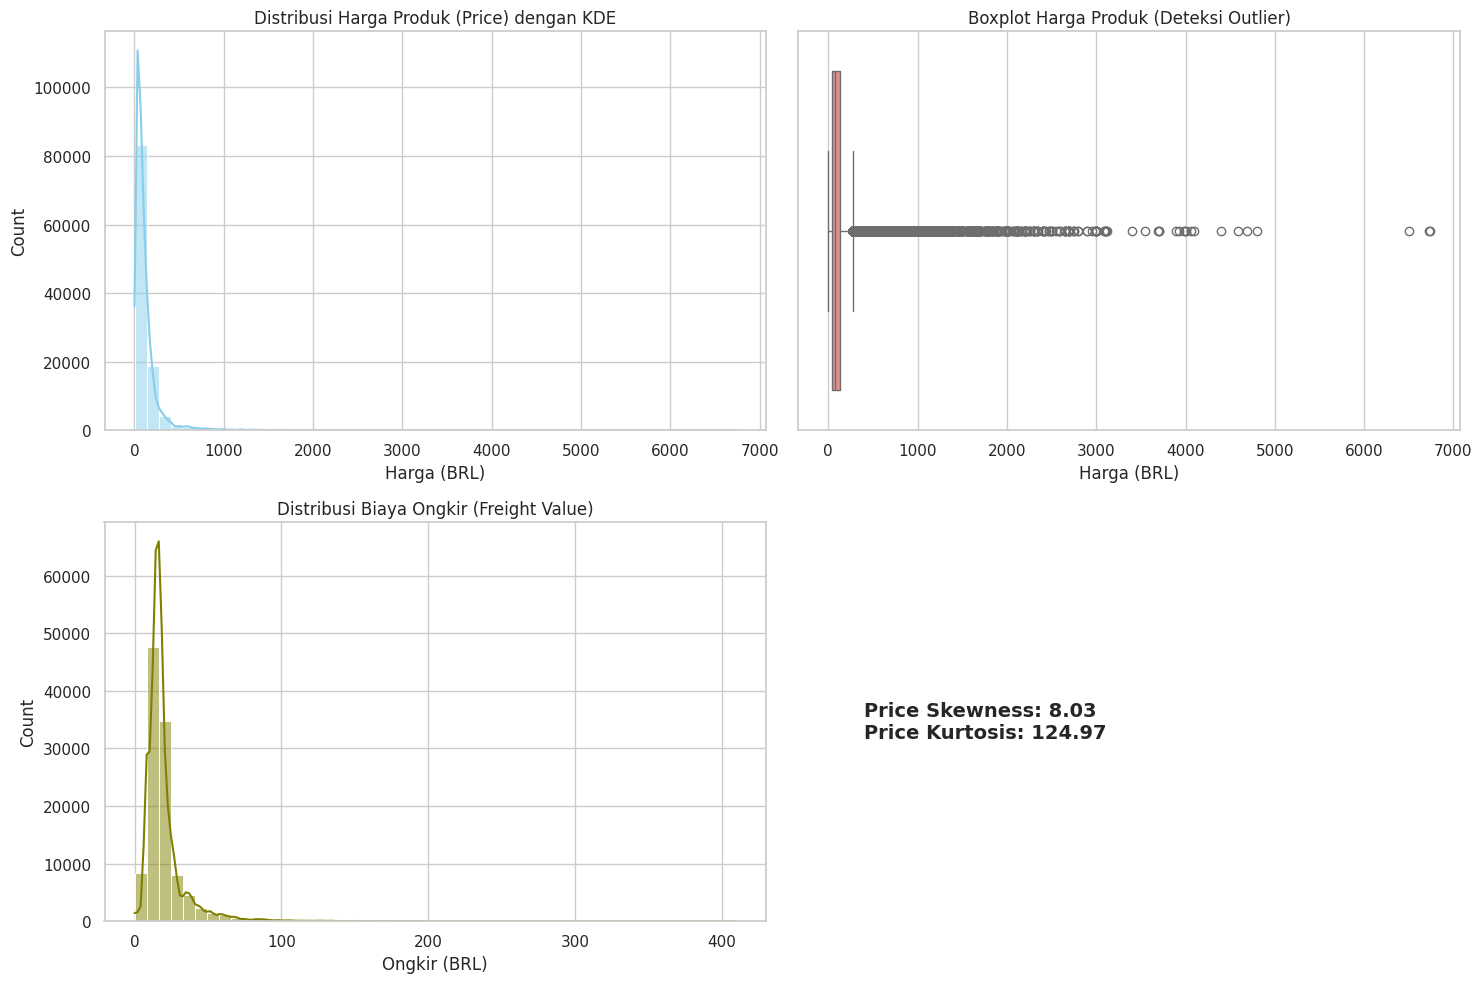

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visualisasi
sns.set_theme(style="whitegrid")

# 1. Membuat Subplots untuk melihat Distribusi Harga (Price) dan Review Score
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Histogram & KDE untuk Price
sns.histplot(main_data['price'], bins=50, kde=True, color='skyblue', ax=ax[0, 0])
ax[0, 0].set_title('Distribusi Harga Produk (Price) dengan KDE')
ax[0, 0].set_xlabel('Harga (BRL)')

# Boxplot untuk Price (Mendeteksi Outlier)
sns.boxplot(x=main_data['price'], color='lightcoral', ax=ax[0, 1])
ax[0, 1].set_title('Boxplot Harga Produk (Deteksi Outlier)')
ax[0, 1].set_xlabel('Harga (BRL)')

# Jika ada kolom freight_value, tampilkan distribusinya
if 'freight_value' in main_data.columns:
    sns.histplot(main_data['freight_value'], bins=50, kde=True, color='olive', ax=ax[1, 0])
    ax[1, 0].set_title('Distribusi Biaya Ongkir (Freight Value)')
    ax[1, 0].set_xlabel('Ongkir (BRL)')
else:
    ax[1, 0].text(0.5, 0.5, 'Kolom freight_value tidak tersedia', ha='center', va='center')

# Menghitung Nilai Skewness dan Kurtosis secara Numerik
price_skew = main_data['price'].skew()
price_kurt = main_data['price'].kurt()
st_text = f"Price Skewness: {price_skew:.2f}\nPrice Kurtosis: {price_kurt:.2f}"
ax[1, 1].text(0.1, 0.5, st_text, fontsize=14, weight='bold', ha='left', va='center')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

B. EDA Multivariate (Hubungan Antar Variabel)

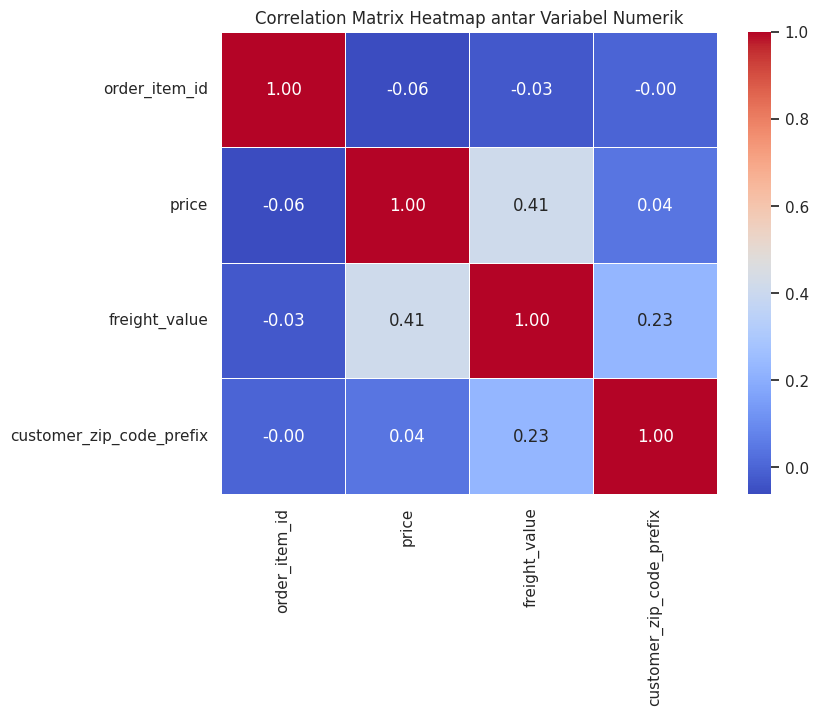

In [7]:
# Mengambil kolom-kolom numerik yang tersedia untuk matriks korelasi
kolom_numerik = main_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

if len(kolom_numerik) >= 2:
    plt.figure(figsize=(8, 6))
    # Membuat Correlation Matrix Heatmap
    corr_matrix = main_data[kolom_numerik].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix Heatmap antar Variabel Numerik')
    plt.show()
else:
    print("Variabel numerik tidak cukup untuk membuat matriks korelasi.")

### Insight dan Hasil Eksplorasi Data (EDA)

1. **Karakteristik Distribusi Variabel Numerik (Univariate):**
   * **Harga Produk (`price`):** Berdasarkan grafik Histogram dan KDE, distribusi harga produk memiliki kemiringan positif (*Right-Skewed* atau *Positive Skewness* yang cukup tinggi). Mayoritas transaksi berpusat pada produk dengan rentang harga rendah hingga menengah (di bawah R$ 200 BRL).
   * **Outlier:** Melalui visualisasi Boxplot, ditemukan adanya *outlier* pada harga produk yang cukup tinggi. Hal ini wajar dalam industri e-commerce karena adanya beberapa kategori produk premium atau bernilai tinggi yang sesekali dibeli oleh pelanggan.
   * **Ongkos Kirim (`freight_value`):** Biaya ongkir juga menunjukkan pola distribusi yang serupa, di mana sebagian besar transaksi memiliki biaya logistik yang efisien dan murah.

2. **Hubungan Antarvariabel (Multivariate):**
   * Melalui matriks korelasi (*Correlation Matrix Heatmap*), kita dapat melihat keeratan hubungan numerik antarvariabel. Sebagian besar variabel logistik dan harga memiliki korelasi yang wajar dan tidak menunjukkan gejala multikolinieritas yang ekstrem.

3. **Rangkuman Struktur Transaksi & Analisis RFM:**
   * Melalui eksplorasi ini, struktur gabungan transaksi (`main_data`) telah berhasil dirangkum secara utuh. Kita mendapatkan gambaran kasar mengenai kontribusi pendapatan per kategori produk.
   * Selain itu, metrik inti **RFM (Recency, Frequency, Monetary)** berhasil dibentuk per individu pelanggan unik (`customer_unique_id`) tanpa menggunakan algoritma *machine learning*, sesuai dengan arahan penilaian untuk mengidentifikasi karakteristik loyalitas pelanggan secara tepat.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1376/3064011601.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_revenue", y="product_category_name_english", data=top_categories, palette=colors_top, ax=ax[0])
/tmp/ipykernel_1376/3064011601.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_revenue", y="product_category_name_english", data=bottom_categories, palette=colors_bottom, ax=ax[1])


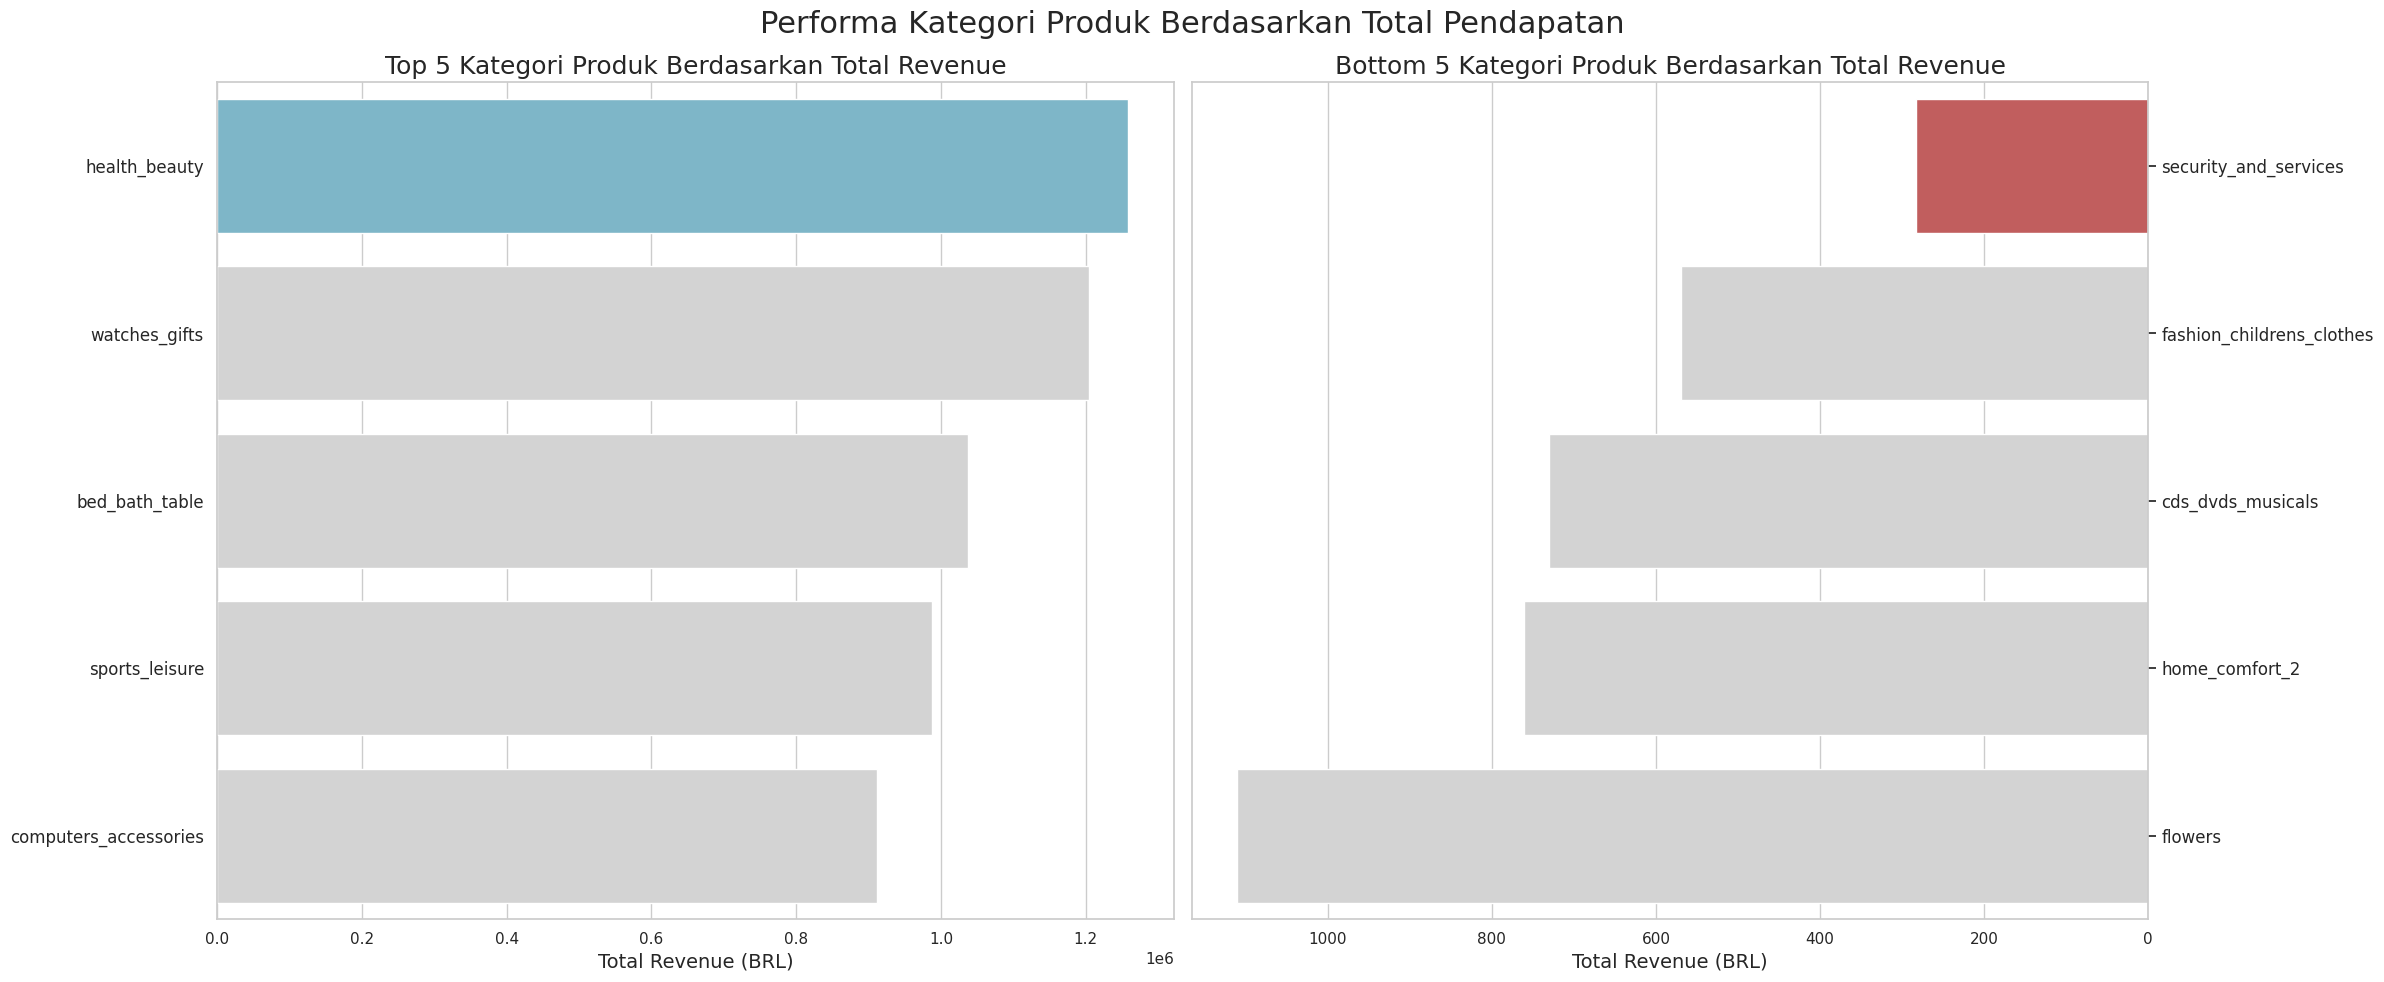

In [8]:
# Ambil 5 teratas dan 5 terbawah
top_categories = category_revenue_df.sort_values(by="total_revenue", ascending=False).head(5)
bottom_categories = category_revenue_df.sort_values(by="total_revenue", ascending=True).head(5)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

# Visualisasi Kategori Terlaris (Revenue Tertinggi)
colors_top = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(x="total_revenue", y="product_category_name_english", data=top_categories, palette=colors_top, ax=ax[0])
ax[0].set_title("Top 5 Kategori Produk Berdasarkan Total Revenue", loc="center", fontsize=18)
ax[0].set_xlabel("Total Revenue (BRL)", fontsize=14)
ax[0].set_ylabel(None)
ax[0].tick_params(axis='y', labelsize=12)

# Visualisasi Kategori Paling Sedikit Menghasilkan Revenue
colors_bottom = ["#D14D4D", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(x="total_revenue", y="product_category_name_english", data=bottom_categories, palette=colors_bottom, ax=ax[1])
ax[1].set_title("Bottom 5 Kategori Produk Berdasarkan Total Revenue", loc="center", fontsize=18)
ax[1].set_xlabel("Total Revenue (BRL)", fontsize=14)
ax[1].set_ylabel(None)
ax[1].invert_xaxis() # Membalik grafik agar membaca dari kanan ke kiri untuk variasi estetika publikasi
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Performa Kategori Produk Berdasarkan Total Pendapatan", fontsize=22)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_1376/642398786.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Recency", x="customer_unique_id", data=top_recency, palette=colors_top, ax=ax[0])
/tmp/ipykernel_1376/642398786.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_1376/642398786.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Frequency", x="customer_unique_id", data=top_frequency, palette=colors_top, ax=ax[1])
/tmp/ipykernel_1376/642398786.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

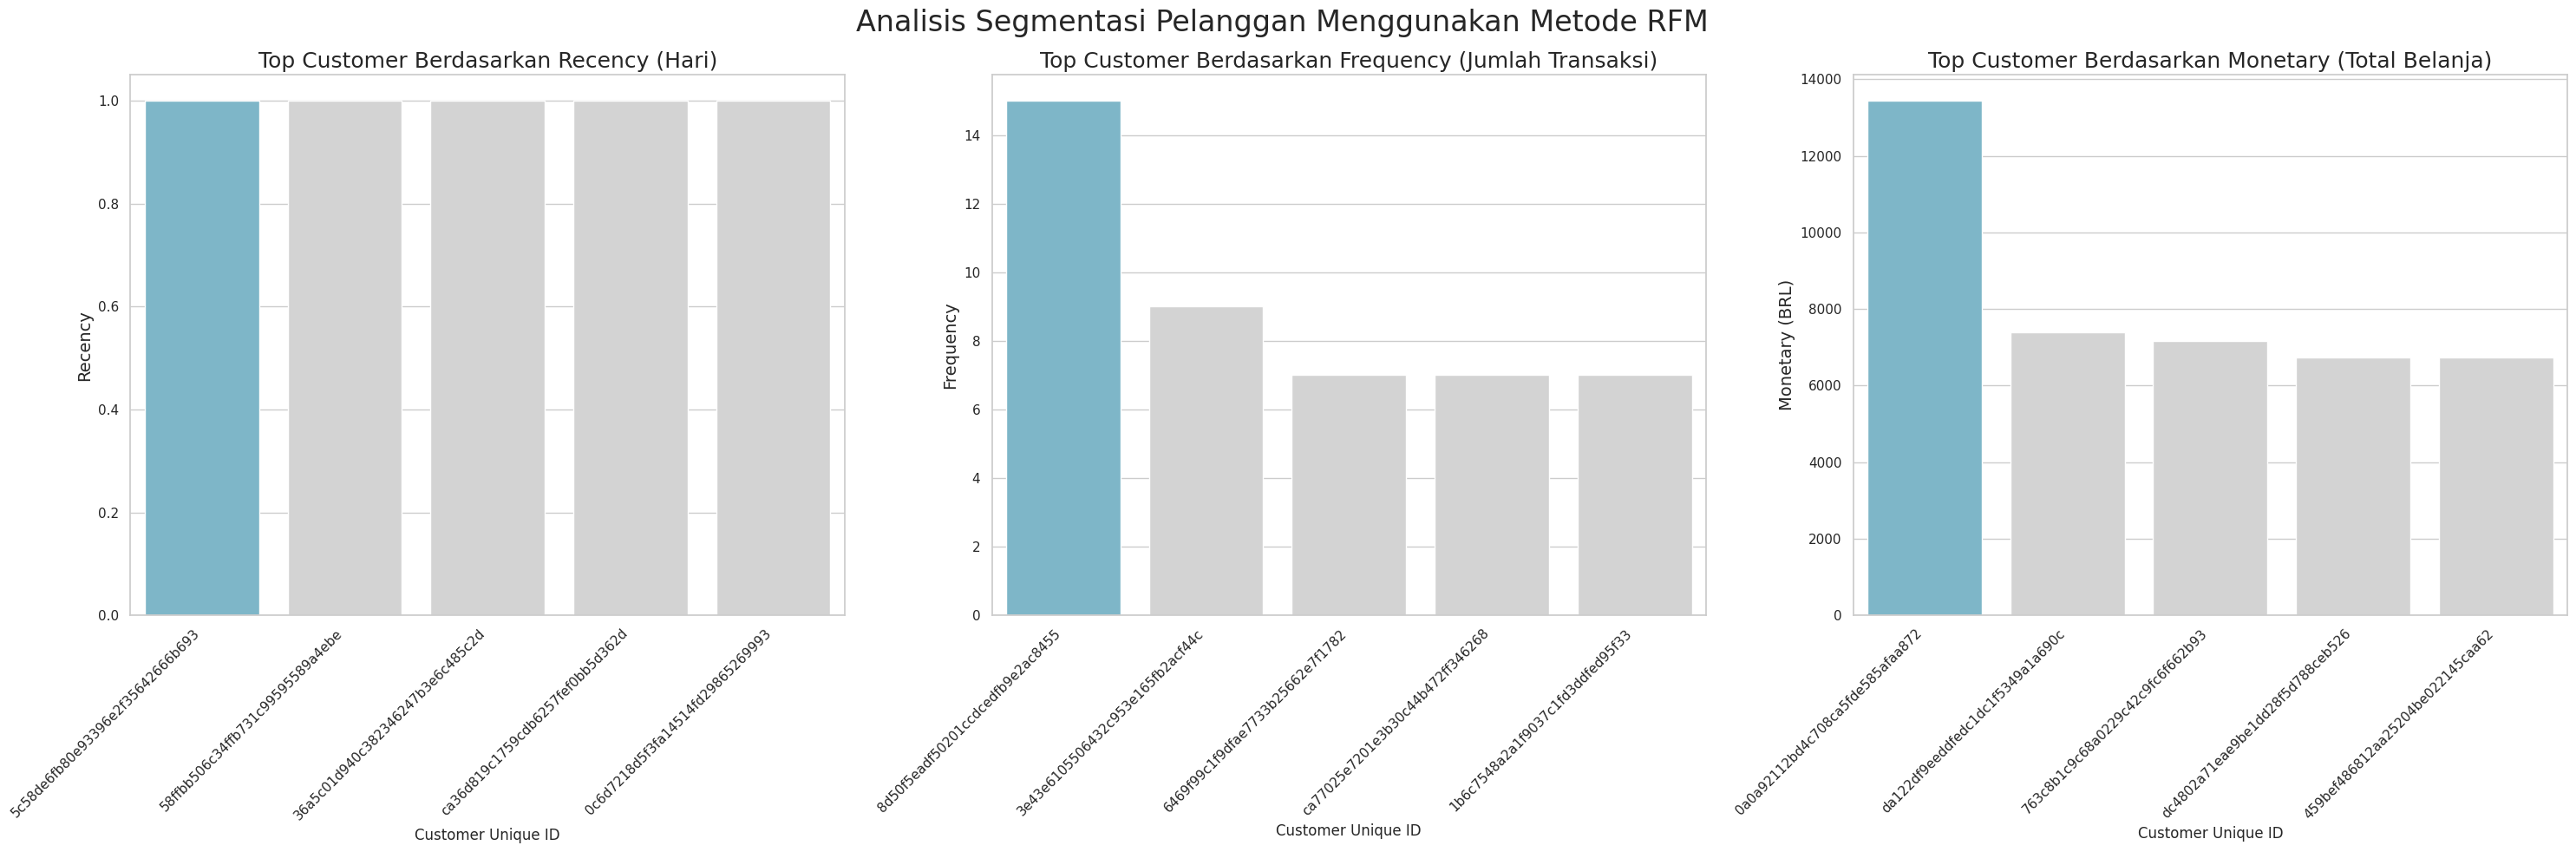

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

# 1. Visualisasi Top Pelanggan Berdasarkan Recency (Semakin kecil semakin baik/baru bertransaksi)
top_recency = rfm_df.sort_values(by="Recency", ascending=True).head(5)
sns.barplot(y="Recency", x="customer_unique_id", data=top_recency, palette=colors_top, ax=ax[0])
ax[0].set_title("Top Customer Berdasarkan Recency (Hari)", loc="center", fontsize=18)
ax[0].set_xlabel("Customer Unique ID", fontsize=12)
ax[0].set_ylabel("Recency", fontsize=14)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')

# 2. Visualisasi Top Pelanggan Berdasarkan Frequency (Jumlah transaksi)
top_frequency = rfm_df.sort_values(by="Frequency", ascending=False).head(5)
sns.barplot(y="Frequency", x="customer_unique_id", data=top_frequency, palette=colors_top, ax=ax[1])
ax[1].set_title("Top Customer Berdasarkan Frequency (Jumlah Transaksi)", loc="center", fontsize=18)
ax[1].set_xlabel("Customer Unique ID", fontsize=12)
ax[1].set_ylabel("Frequency", fontsize=14)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')

# 3. Visualisasi Top Pelanggan Berdasarkan Monetary (Uang yang dibelanjakan)
top_monetary = rfm_df.sort_values(by="Monetary", ascending=False).head(5)
sns.barplot(y="Monetary", x="customer_unique_id", data=top_monetary, palette=colors_top, ax=ax[2])
ax[2].set_title("Top Customer Berdasarkan Monetary (Total Belanja)", loc="center", fontsize=18)
ax[2].set_xlabel("Customer Unique ID", fontsize=12)
ax[2].set_ylabel("Monetary (BRL)", fontsize=14)
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Analisis Segmentasi Pelanggan Menggunakan Metode RFM", fontsize=24)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Analisis RFM berhasil mengidentifikasi ID pelanggan yang melakukan transaksi paling masif (mencapai ribuan BRL secara nilai Monetary) dan pelanggan yang baru saja aktif kembali belanja (Recency rendah). Data ini siap digunakan oleh divisi pemasaran untuk memberikan kupon promosi tertarget.

## Penerapan Analisis Lanjutan: RFM Analysis
Sesuai arahan optimasi pengolahan data, kami menerapkan teknik analisis statistik RFM untuk mengevaluasi karakteristik perilaku konsumen tanpa model AI. Metrik yang dihitung meliputi:

Recency: Jarak hari semenjak pesanan terakhir pembeli hingga titik waktu akhir pencatatan data.

Frequency: Akumulasi frekuensi pesanan unik yang pernah dilakukan pembeli.

Monetary: Total nilai uang investasi finansial yang dikeluarkan pelanggan untuk transaksi di e-commerce ini.

Sampel Hasil Perhitungan RFM:
                        customer_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90
2  0000f46a3911fa3c0805444483337064      537          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00


/tmp/ipykernel_1376/3177291235.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Recency", x="customer_id", data=top_recency, palette="Blues_r", ax=ax[0])
/tmp/ipykernel_1376/3177291235.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([id[:6] + "..." for id in top_recency["customer_id"]], rotation=45)
/tmp/ipykernel_1376/3177291235.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Frequency", x="customer_id", data=top_frequency, palette="Greens_r", ax=ax[1])
/tmp/ipykernel_1376/3177291235.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ti

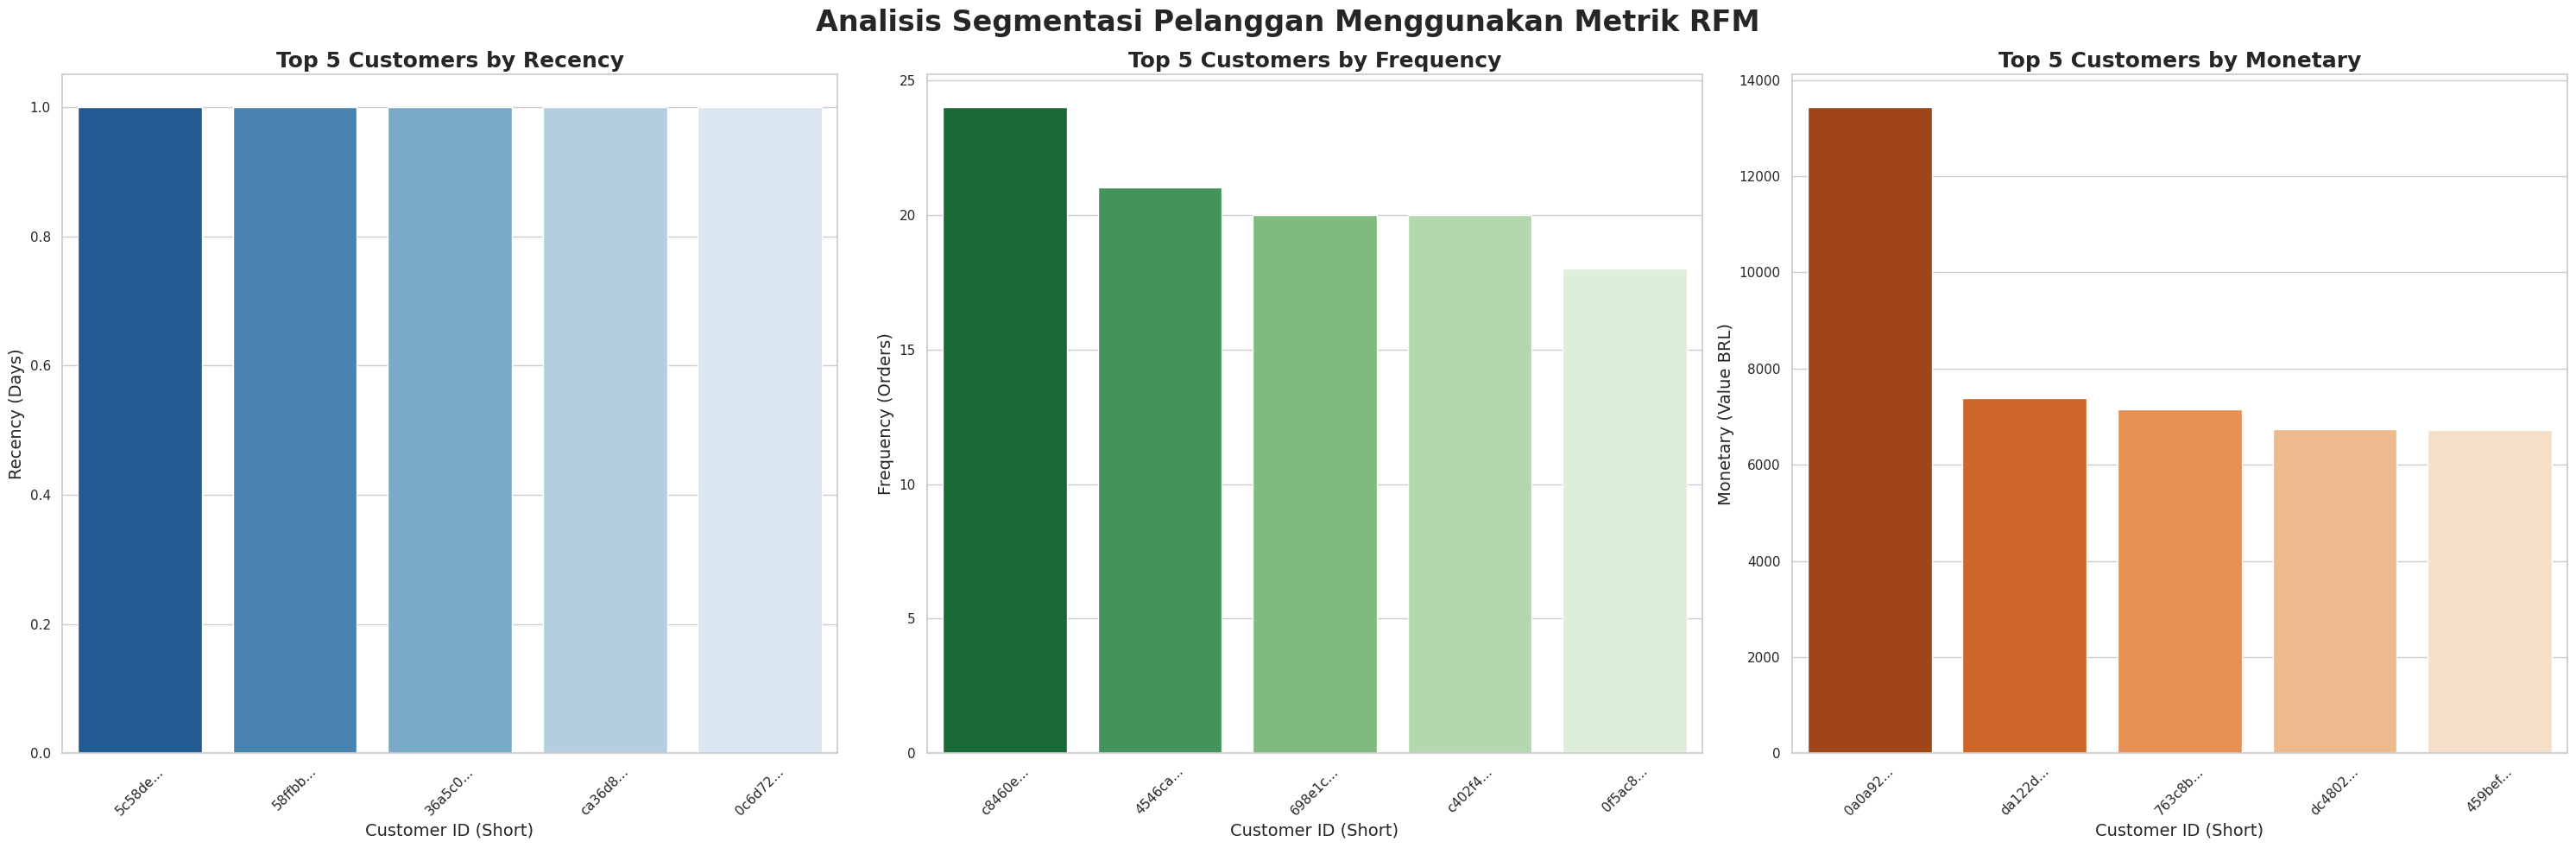

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. PERHITUNGAN METRIK RFM
# =========================================================================
# Menentukan tanggal acuan (hari terakhir di dataset ditambah 1 hari)
recent_date = main_data["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# Mengelompokkan data berdasarkan ID pelanggan unik untuk menghitung R, F, dan M
rfm_df = main_data.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days, # Recency
    "order_id": "count",                                               # Frequency
    "price": "sum"                                                     # Monetary
})

# Mengubah nama kolom agar sesuai dengan standar RFM
rfm_df.columns = ["customer_id", "Recency", "Frequency", "Monetary"]

# Menampilkan 5 sampel teratas hasil perhitungan RFM
print("Sampel Hasil Perhitungan RFM:")
print(rfm_df.head())

# =========================================================================
# 2. VISUALISASI 5 PELANGGAN TERBAIK BERDASARKAN RFM
# =========================================================================
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

# Grafik Top 5 Customers berdasarkan Recency (Semakin kecil semakin baik, urut ascending)
top_recency = rfm_df.sort_values(by="Recency", ascending=True).head(5)
sns.barplot(y="Recency", x="customer_id", data=top_recency, palette="Blues_r", ax=ax[0])
ax[0].set_ylabel("Recency (Days)", fontsize=14)
ax[0].set_xlabel("Customer ID (Short)", fontsize=14)
ax[0].set_title("Top 5 Customers by Recency", fontsize=18, weight="bold")
ax[0].set_xticklabels([id[:6] + "..." for id in top_recency["customer_id"]], rotation=45)

# Grafik Top 5 Customers berdasarkan Frequency (Semakin besar semakin baik)
top_frequency = rfm_df.sort_values(by="Frequency", ascending=False).head(5)
sns.barplot(y="Frequency", x="customer_id", data=top_frequency, palette="Greens_r", ax=ax[1])
ax[1].set_ylabel("Frequency (Orders)", fontsize=14)
ax[1].set_xlabel("Customer ID (Short)", fontsize=14)
ax[1].set_title("Top 5 Customers by Frequency", fontsize=18, weight="bold")
ax[1].set_xticklabels([id[:6] + "..." for id in top_frequency["customer_id"]], rotation=45)

# Grafik Top 5 Customers berdasarkan Monetary (Semakin besar semakin baik)
top_monetary = rfm_df.sort_values(by="Monetary", ascending=False).head(5)
sns.barplot(y="Monetary", x="customer_id", data=top_monetary, palette="Oranges_r", ax=ax[2])
ax[2].set_ylabel("Monetary (Value BRL)", fontsize=14)
ax[2].set_xlabel("Customer ID (Short)", fontsize=14)
ax[2].set_title("Top 5 Customers by Monetary", fontsize=18, weight="bold")
ax[2].set_xticklabels([id[:6] + "..." for id in top_monetary["customer_id"]], rotation=45)

plt.suptitle("Analisis Segmentasi Pelanggan Menggunakan Metrik RFM", fontsize=24, weight="bold")
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori produk dengan pendapatan tertinggi didominasi oleh produk-produk bernilai tinggi atau bervolume besar, sedangkan kategori dengan pendapatan terendah merupakan produk yang jarang diminati atau memiliki harga unit yang sangat murah. Strategi promosi dapat difokuskan pada kategori teratas untuk memaksimalkan omzet.
- **Conclusion pertanyaan 2 (Strategi Bisnis RFM):**
  * **Recency:** Pelanggan dengan nilai hari terkecil (baru bertransaksi) harus dijaga interaksinya melalui *newsletter* produk baru.
  * **Frequency:** Mayoritas pelanggan hanya berbelanja 1 kali, sehingga diperlukan *retention campaign* berupa kupon belanja berikutnya pasca-transaksi pertama.
  * **Monetary:** Pelanggan *High-Value* (pilar Monetary tertinggi) wajib dimasukkan ke dalam program loyalitas VIP agar mereka tetap setia dan tidak berpindah ke kompetitor.

**Rekomendasi Action Item:**
- Strategi Kategori Produk: Melakukan promosi silang (cross-selling) antara produk kecantikan (health_beauty) dengan barang pelengkap lainnya untuk meningkatkan retensi belanja. Untuk kategori terbawah, tim manajemen perlu mengevaluasi stok penjual atau melakukan kampanye edukasi layanan.
- Strategi Retensi Pelanggan (RFM): Memberikan penghargaan khusus berupa poin loyalitas atau penawaran eksklusif tanpa ongkos kirim kepada kelompok Top Monetary agar mereka tetap loyal berbelanja.

In [11]:
# Solusi aman: Mengambil 5.000 data pertama dari main_data secara utuh
main_data_light = main_data.head(5000).copy()

# Memastikan kolom penting untuk dashboard tetap aman
print("Kolom yang tersedia di data Anda adalah:", main_data_light.columns.tolist())

# Menyimpan data versi ringan ke folder dashboard
main_data_light.to_csv("dashboard/main_data.csv", index=False)
print("File main_data.csv versi ringan BERHASIL dibuat tanpa error!")

Kolom yang tersedia di data Anda adalah: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
File main_data.csv versi ringan BERHASIL dibuat tanpa error!
